# PLB ratio sensitivity

This notebook tests whether the algorithm behavior seen under the balanced workload generalizes to different client compositions.

Compared PLB algorithms:

- N-class PLB
- Target-repair v2
- Target-repair v3
- Target-repair v4

Round-robin is loaded only where a metric is explicitly normalized by RR. It is not plotted as a competing PLB algorithm.

Each workload ratio is plotted separately to avoid mixing too many dimensions in one figure.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CAMPAIGN_DIR = ROOT / "outputs_query" / "plb_ratio_sensitivity"
FIG_ROOT = ROOT / "figures" / "selected" / "plb_ratio_sensitivity"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

RATIOS = [
    ("balanced", "1:1:1"),
    ("enterprise_heavy", "3:1:1"),
    ("premium_heavy", "1:3:1"),
    ("freemium_heavy", "1:1:3"),
]

CLASS_ORDER = ["enterprise", "premium", "freemium"]
CLASS_LABELS = {
    "enterprise": "Enterprise",
    "premium": "Premium",
    "freemium": "Freemium",
}

PLB_SCHEDULERS = [
    "plb_nclass",
    "global_target_repair_target_only",
    "global_target_repair_nomixed",
    "global_target_repair_v4",
]

PLB_LABELS = {
    "plb_nclass": "N-class PLB",
    "global_target_repair_target_only": "Target-repair v2",
    "global_target_repair_nomixed": "Target-repair v3",
    "global_target_repair_v4": "Target-repair v4",
}

LINE_STYLES = {
    "plb_nclass": {"linestyle": "-", "marker": "o", "linewidth": 1.6, "markersize": 3},
    "global_target_repair_target_only": {"linestyle": "--", "marker": "s", "linewidth": 1.5, "markersize": 3},
    "global_target_repair_nomixed": {"linestyle": "-.", "marker": "^", "linewidth": 1.7, "markersize": 3},
    "global_target_repair_v4": {"linestyle": ":", "marker": "D", "linewidth": 1.8, "markersize": 3},
}

print("Campaign:", CAMPAIGN_DIR)
print("Figures:", FIG_ROOT)

Campaign: /home/spirals/phd/experiments/plb_batsim/outputs_query/plb_ratio_sensitivity
Figures: /home/spirals/phd/experiments/plb_batsim/figures/selected/plb_ratio_sensitivity


In [2]:
required = {
    "latency": "class_latency_metrics.csv",
    "concentration": "class_concentration_metrics.csv",
    "decision": "decision_metrics.csv",
}

missing = [filename for filename in required.values() if not (CAMPAIGN_DIR / filename).exists()]
if missing:
    raise FileNotFoundError(
        "Run the ratio campaign first. Missing: " + ", ".join(missing)
    )

latency = pd.read_csv(CAMPAIGN_DIR / required["latency"])
concentration = pd.read_csv(CAMPAIGN_DIR / required["concentration"])
decision = pd.read_csv(CAMPAIGN_DIR / required["decision"])

print("Ratios found:", sorted(latency["ratio"].dropna().unique()))
print("PLB schedulers found:", sorted(set(latency["scheduler"]) & set(PLB_SCHEDULERS)))
print("T levels:", sorted(latency["T"].unique()))

Ratios found: ['balanced', 'enterprise_heavy', 'freemium_heavy', 'premium_heavy']
PLB schedulers found: ['global_target_repair_nomixed', 'global_target_repair_target_only', 'global_target_repair_v4', 'plb_nclass']
T levels: [np.int64(120), np.int64(180), np.int64(240), np.int64(300), np.int64(360), np.int64(420), np.int64(480), np.int64(540), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1200), np.int64(1400), np.int64(1600), np.int64(1800), np.int64(2000)]


## How to read the plots

For each ratio, inspect the plots in this order:

1. Q1 latency p50 by priority.
2. Q1 latency p95 by priority.
3. Priority-ordering gap p50 and p95.
4. Effective replicas by priority.
5. Freemium cost relative to RR.

The three priority panels always share the same y-axis so differences between Enterprise, Premium, and Freemium remain visually comparable.

In [3]:
def save_ratio_figure(fig, ratio, name):
    ratio_dir = FIG_ROOT / f"ratio_{ratio}"
    ratio_dir.mkdir(parents=True, exist_ok=True)
    path = ratio_dir / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight")
    print("saved", path.relative_to(ROOT))


def available_plb(df, ratio):
    present = set(df.loc[df["ratio"] == ratio, "scheduler"])
    return [s for s in PLB_SCHEDULERS if s in present]


def plot_latency_for_ratio(ratio, ratio_label, quantile):
    metric = f"latency_{quantile}_s"
    data = latency[
        (latency["ratio"] == ratio)
        & (latency["scheduler"].isin(PLB_SCHEDULERS))
        & (latency["class"].isin(CLASS_ORDER))
    ].copy()

    schedulers = available_plb(latency, ratio)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)

    for ax, cls in zip(axes, CLASS_ORDER):
        for sched in schedulers:
            sdata = data[
                (data["class"] == cls) & (data["scheduler"] == sched)
            ].sort_values("T")
            if not sdata.empty:
                ax.plot(
                    sdata["T"],
                    sdata[metric],
                    label=PLB_LABELS[sched],
                    **LINE_STYLES[sched],
                )
        ax.set_title(CLASS_LABELS[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"Q1 latency {quantile} (s)")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(f"Ratio {ratio_label}: Q1 latency {quantile}")
    fig.tight_layout()
    save_ratio_figure(fig, ratio, f"latency_{quantile}")
    plt.show()


def plot_priority_gap_for_ratio(ratio, ratio_label, quantile):
    metric = f"priority_violation_gap_{quantile}_s"
    data = decision[
        (decision["ratio"] == ratio)
        & (decision["scheduler"].isin(PLB_SCHEDULERS))
    ].copy()

    fig, ax = plt.subplots(figsize=(7.4, 4.0))
    for sched in available_plb(decision, ratio):
        sdata = data[data["scheduler"] == sched].sort_values("T")
        if not sdata.empty:
            ax.plot(
                sdata["T"],
                sdata[metric],
                label=PLB_LABELS[sched],
                **LINE_STYLES[sched],
            )

    ax.axhline(0.0, linewidth=0.8)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Priority-ordering gap {quantile} (s)")
    ax.set_title(f"Ratio {ratio_label}: priority-ordering gap {quantile}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.tight_layout()
    save_ratio_figure(fig, ratio, f"priority_gap_{quantile}")
    plt.show()


def plot_effective_replicas_for_ratio(ratio, ratio_label):
    data = concentration[
        (concentration["ratio"] == ratio)
        & (concentration["scheduler"].isin(PLB_SCHEDULERS))
        & (concentration["class"].isin(CLASS_ORDER))
    ].copy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)

    for ax, cls in zip(axes, CLASS_ORDER):
        for sched in available_plb(concentration, ratio):
            sdata = data[
                (data["class"] == cls) & (data["scheduler"] == sched)
            ].sort_values("T")
            if not sdata.empty:
                ax.plot(
                    sdata["T"],
                    sdata["effective_replicas"],
                    label=PLB_LABELS[sched],
                    **LINE_STYLES[sched],
                )
        ax.set_title(CLASS_LABELS[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel("Effective replicas")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.suptitle(f"Ratio {ratio_label}: effective replicas")
    fig.tight_layout()
    save_ratio_figure(fig, ratio, "effective_replicas")
    plt.show()


def plot_freemium_cost_for_ratio(ratio, ratio_label, quantile):
    metric = f"freemium_cost_vs_round_robin_{quantile}"
    data = decision[
        (decision["ratio"] == ratio)
        & (decision["scheduler"].isin(PLB_SCHEDULERS))
    ].copy()

    fig, ax = plt.subplots(figsize=(7.4, 4.0))
    for sched in available_plb(decision, ratio):
        sdata = data[data["scheduler"] == sched].sort_values("T")
        if not sdata.empty:
            ax.plot(
                sdata["T"],
                sdata[metric],
                label=PLB_LABELS[sched],
                **LINE_STYLES[sched],
            )

    ax.axhline(1.0, linewidth=0.8)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Freemium / RR Q1 latency {quantile}")
    ax.set_title(f"Ratio {ratio_label}: Freemium cost {quantile}")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
    fig.tight_layout()
    save_ratio_figure(fig, ratio, f"freemium_cost_{quantile}")
    plt.show()

## Ratio 1:1:1

Workload composition: `balanced`.

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/latency_p50.pdf


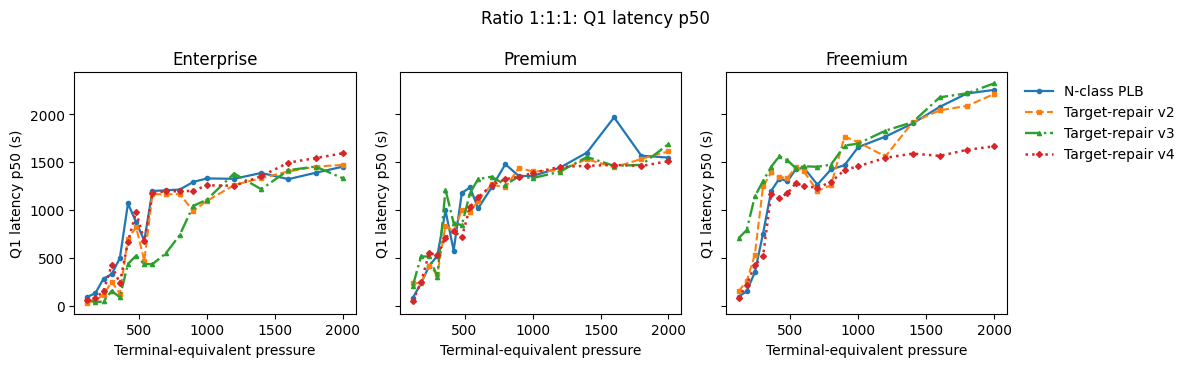

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/latency_p95.pdf


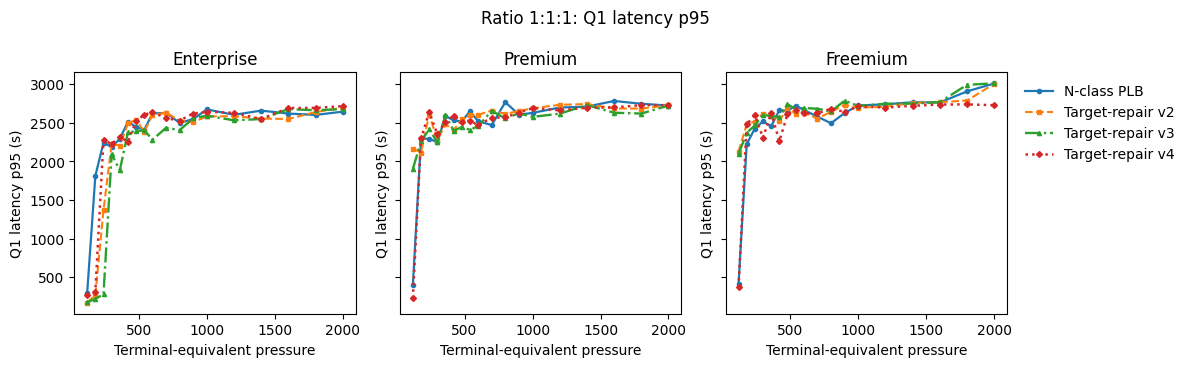

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/priority_gap_p50.pdf


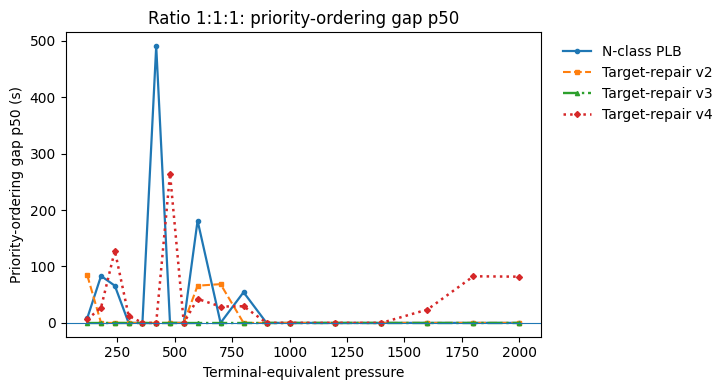

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/priority_gap_p95.pdf


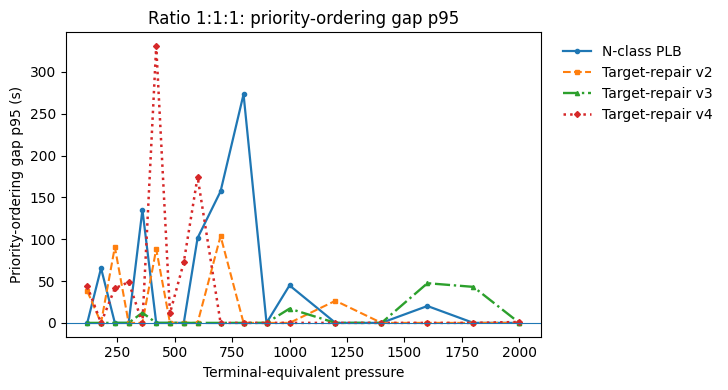

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/effective_replicas.pdf


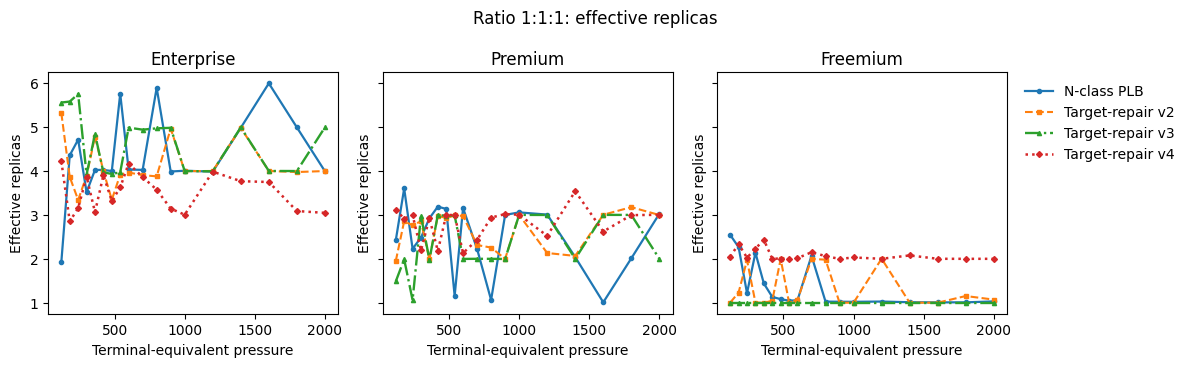

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/freemium_cost_p50.pdf


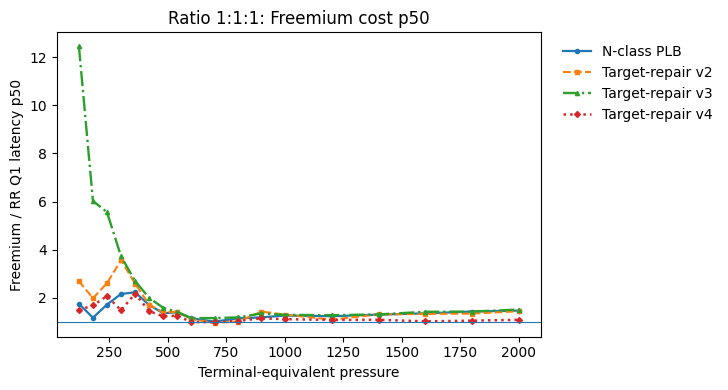

saved figures/selected/plb_ratio_sensitivity/ratio_balanced/freemium_cost_p95.pdf


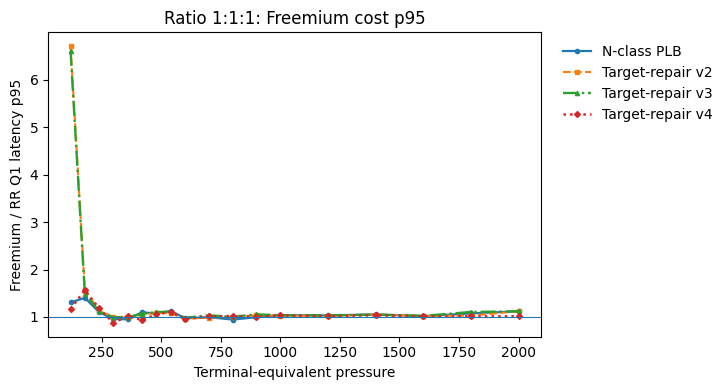

In [4]:
plot_latency_for_ratio("balanced", "1:1:1", "p50")
plot_latency_for_ratio("balanced", "1:1:1", "p95")
plot_priority_gap_for_ratio("balanced", "1:1:1", "p50")
plot_priority_gap_for_ratio("balanced", "1:1:1", "p95")
plot_effective_replicas_for_ratio("balanced", "1:1:1")
plot_freemium_cost_for_ratio("balanced", "1:1:1", "p50")
plot_freemium_cost_for_ratio("balanced", "1:1:1", "p95")

## Ratio 3:1:1

Workload composition: `enterprise_heavy`.

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/latency_p50.pdf


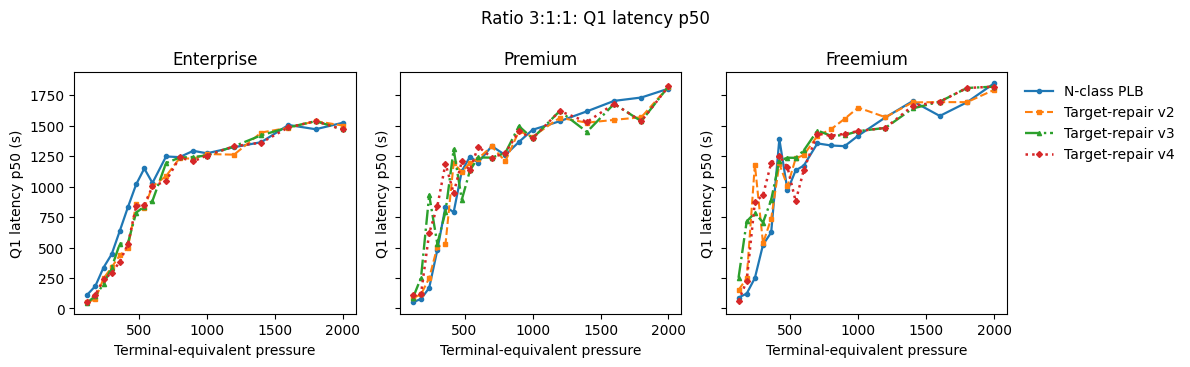

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/latency_p95.pdf


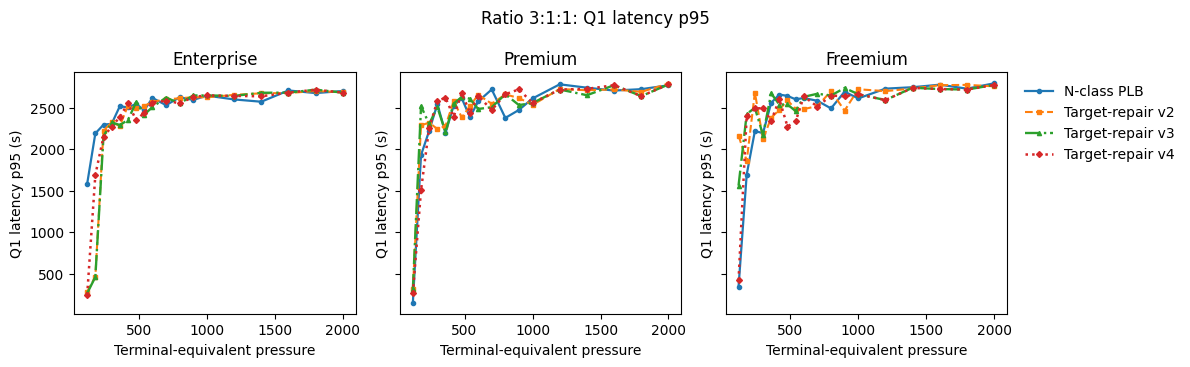

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/priority_gap_p50.pdf


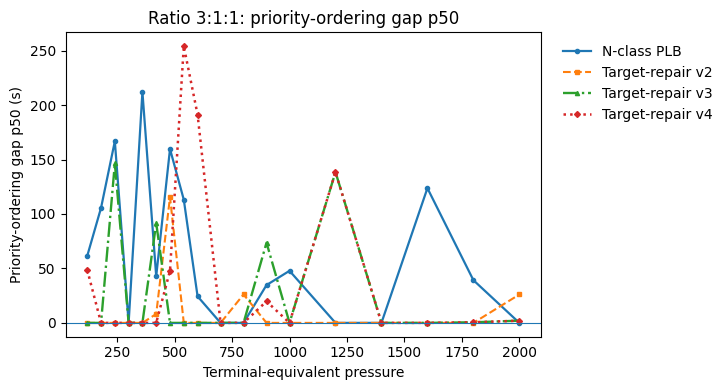

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/priority_gap_p95.pdf


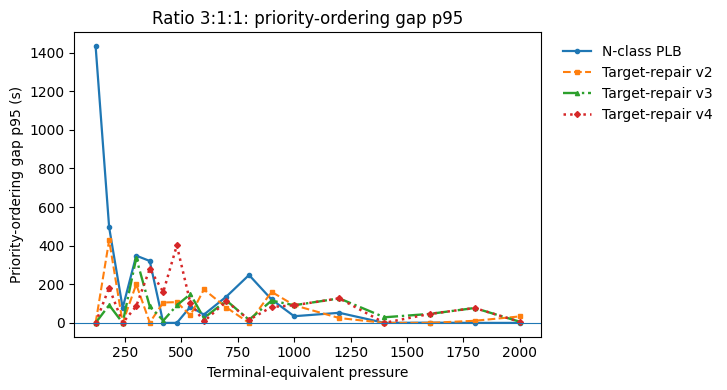

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/effective_replicas.pdf


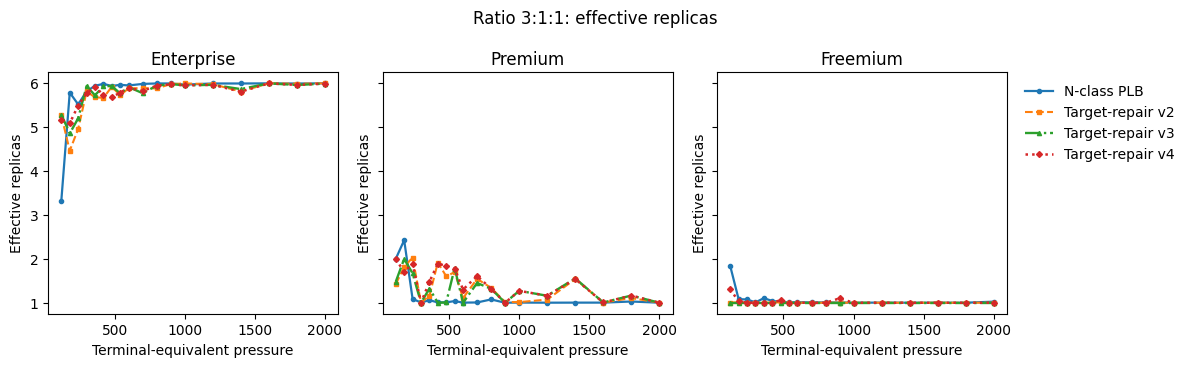

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/freemium_cost_p50.pdf


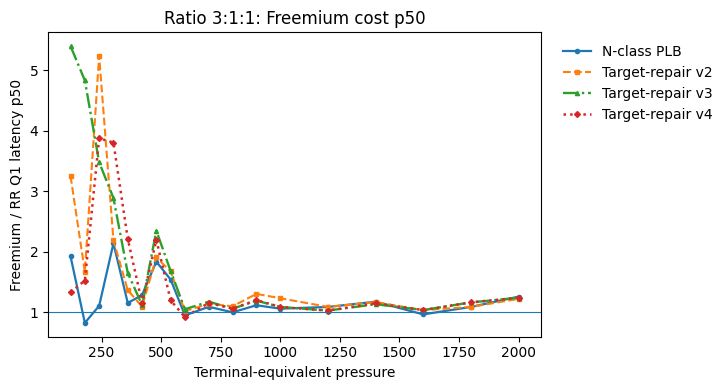

saved figures/selected/plb_ratio_sensitivity/ratio_enterprise_heavy/freemium_cost_p95.pdf


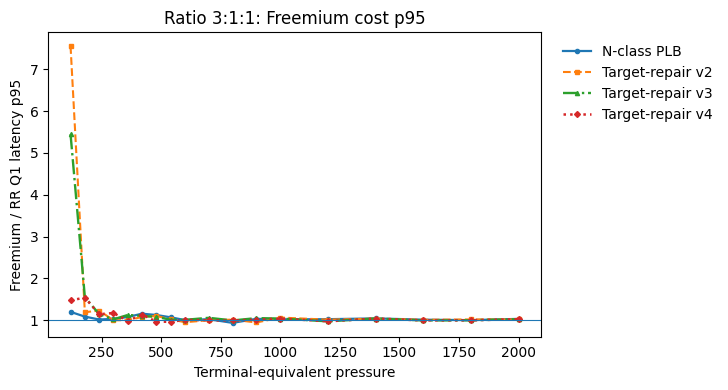

In [5]:
plot_latency_for_ratio("enterprise_heavy", "3:1:1", "p50")
plot_latency_for_ratio("enterprise_heavy", "3:1:1", "p95")
plot_priority_gap_for_ratio("enterprise_heavy", "3:1:1", "p50")
plot_priority_gap_for_ratio("enterprise_heavy", "3:1:1", "p95")
plot_effective_replicas_for_ratio("enterprise_heavy", "3:1:1")
plot_freemium_cost_for_ratio("enterprise_heavy", "3:1:1", "p50")
plot_freemium_cost_for_ratio("enterprise_heavy", "3:1:1", "p95")

## Ratio 1:3:1

Workload composition: `premium_heavy`.

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/latency_p50.pdf


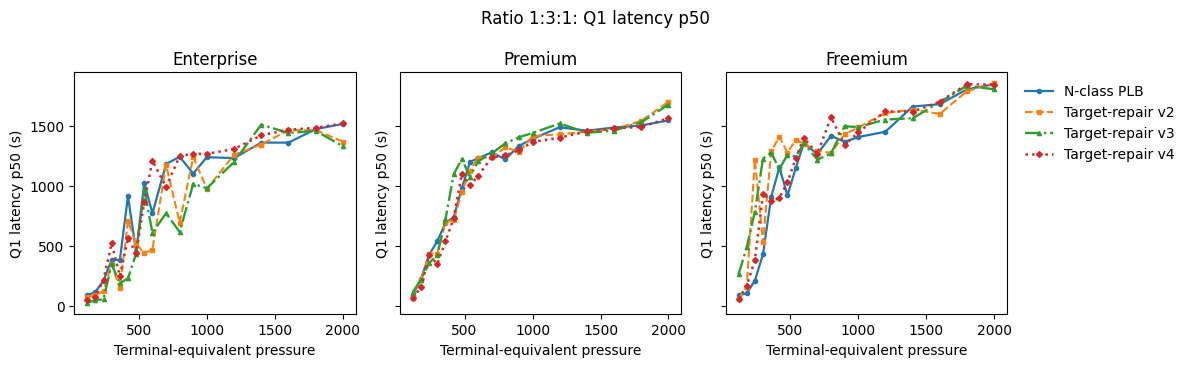

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/latency_p95.pdf


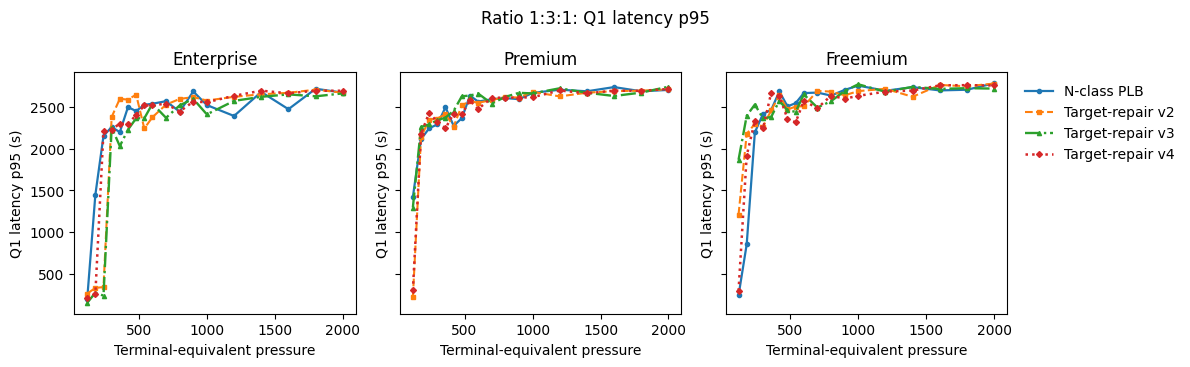

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/priority_gap_p50.pdf


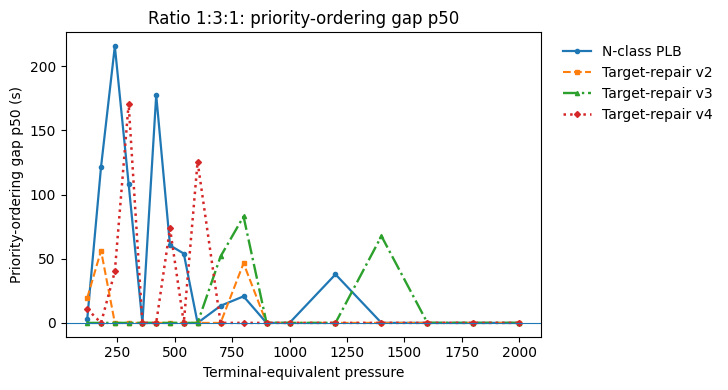

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/priority_gap_p95.pdf


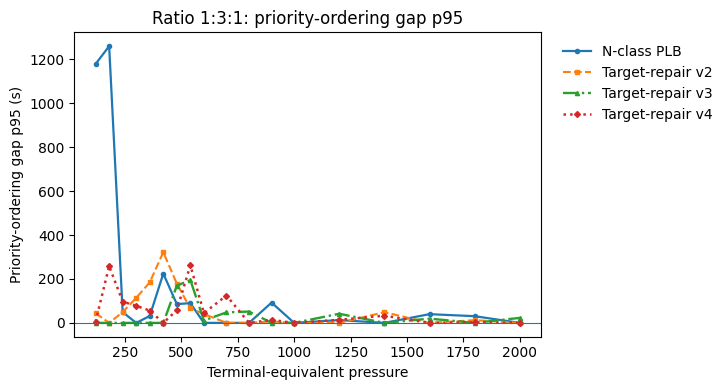

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/effective_replicas.pdf


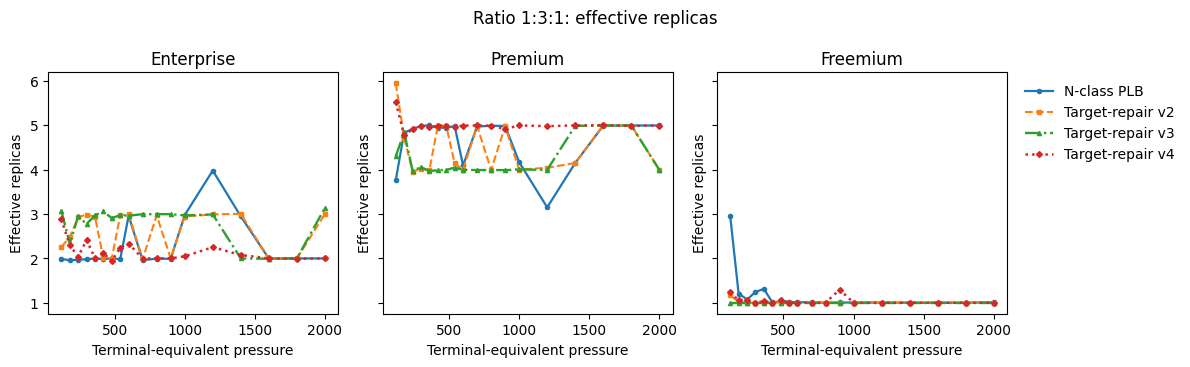

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/freemium_cost_p50.pdf


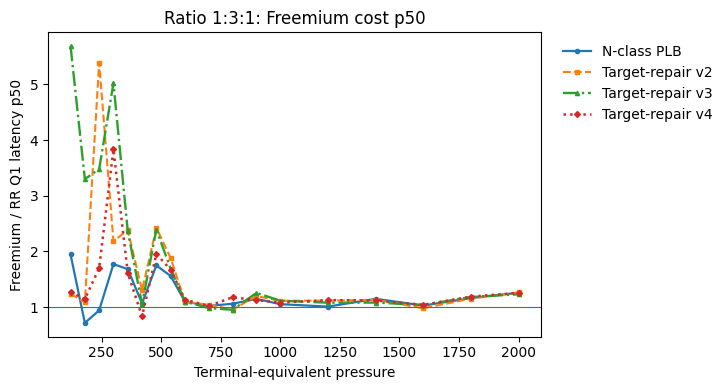

saved figures/selected/plb_ratio_sensitivity/ratio_premium_heavy/freemium_cost_p95.pdf


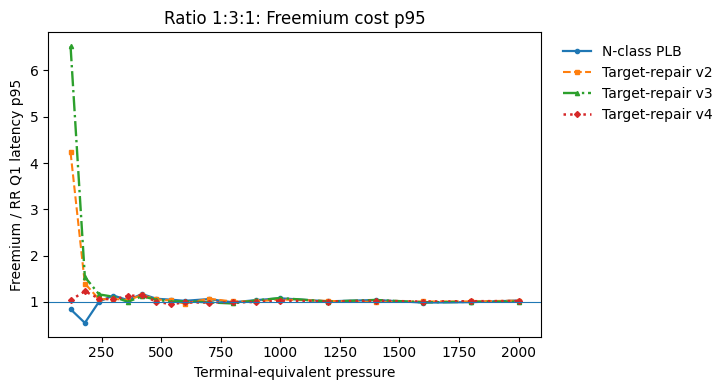

In [6]:
plot_latency_for_ratio("premium_heavy", "1:3:1", "p50")
plot_latency_for_ratio("premium_heavy", "1:3:1", "p95")
plot_priority_gap_for_ratio("premium_heavy", "1:3:1", "p50")
plot_priority_gap_for_ratio("premium_heavy", "1:3:1", "p95")
plot_effective_replicas_for_ratio("premium_heavy", "1:3:1")
plot_freemium_cost_for_ratio("premium_heavy", "1:3:1", "p50")
plot_freemium_cost_for_ratio("premium_heavy", "1:3:1", "p95")

## Ratio 1:1:3

Workload composition: `freemium_heavy`.

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/latency_p50.pdf


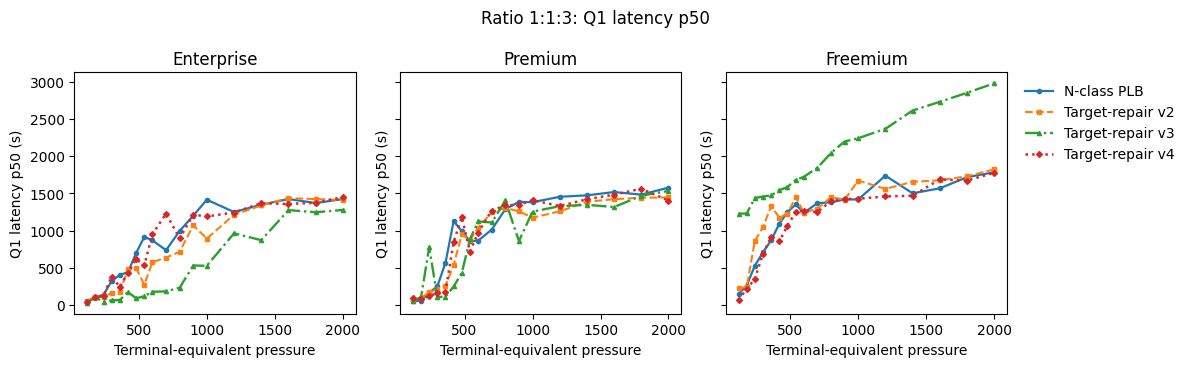

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/latency_p95.pdf


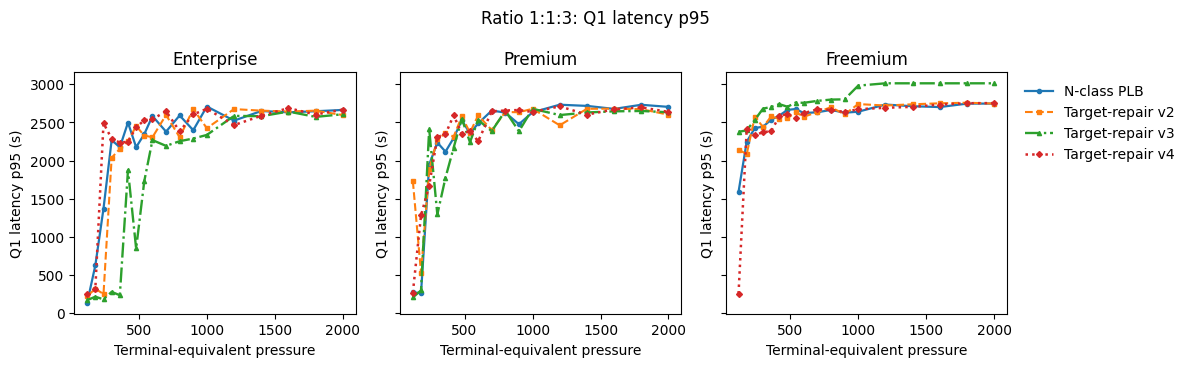

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/priority_gap_p50.pdf


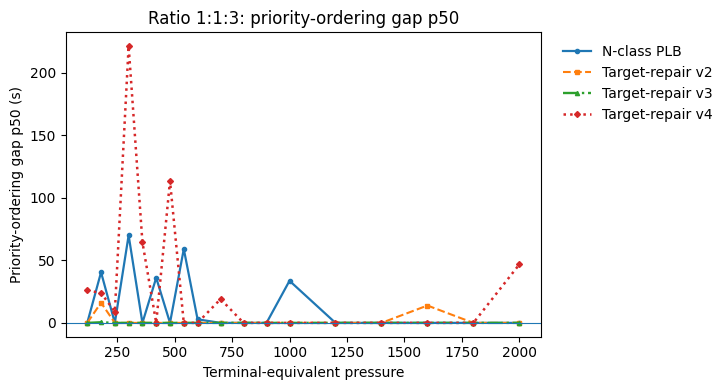

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/priority_gap_p95.pdf


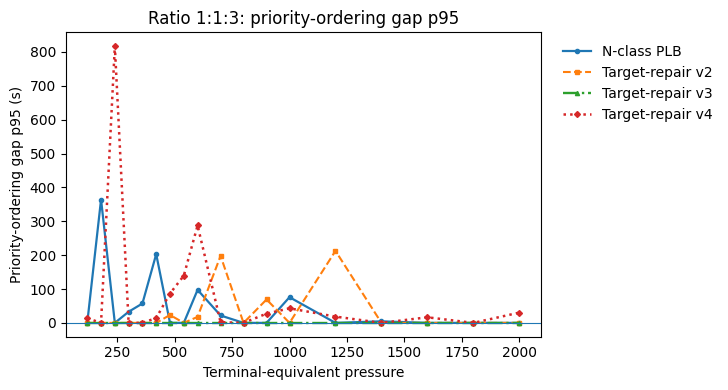

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/effective_replicas.pdf


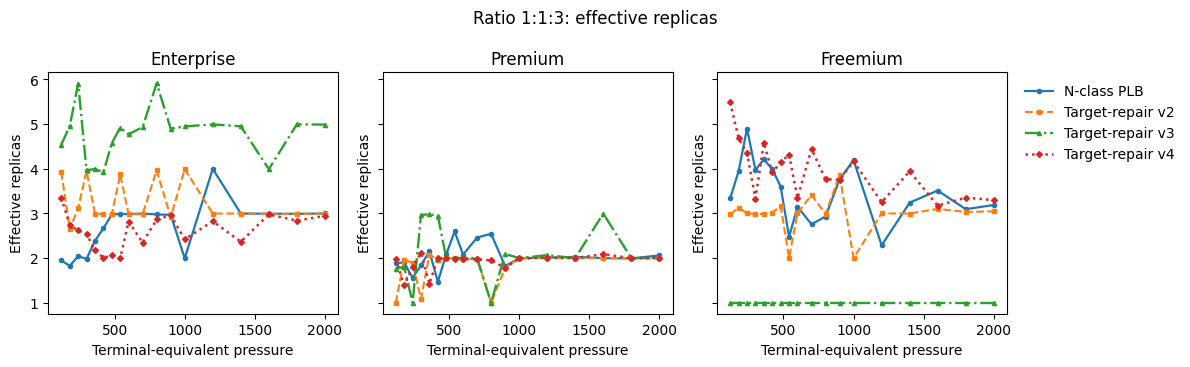

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/freemium_cost_p50.pdf


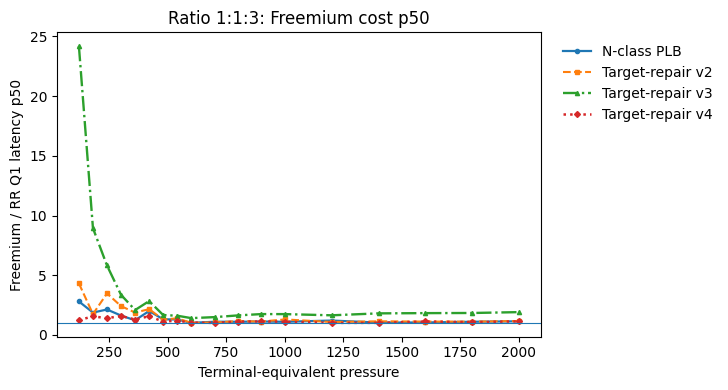

saved figures/selected/plb_ratio_sensitivity/ratio_freemium_heavy/freemium_cost_p95.pdf


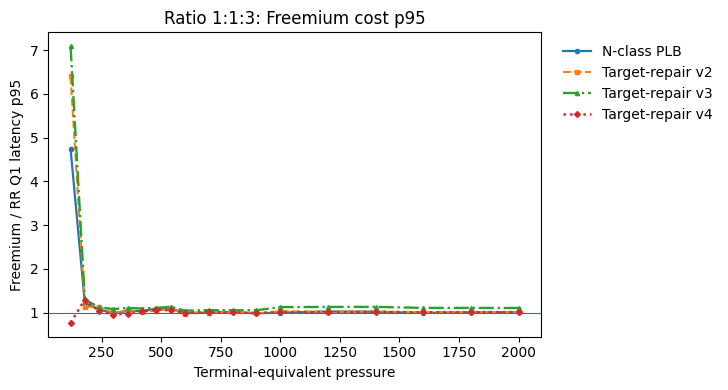

In [7]:
plot_latency_for_ratio("freemium_heavy", "1:1:3", "p50")
plot_latency_for_ratio("freemium_heavy", "1:1:3", "p95")
plot_priority_gap_for_ratio("freemium_heavy", "1:1:3", "p50")
plot_priority_gap_for_ratio("freemium_heavy", "1:1:3", "p95")
plot_effective_replicas_for_ratio("freemium_heavy", "1:1:3")
plot_freemium_cost_for_ratio("freemium_heavy", "1:1:3", "p50")
plot_freemium_cost_for_ratio("freemium_heavy", "1:1:3", "p95")

## Compact violation table

This table does not average the latency gaps. It only counts, for each ratio and algorithm, at how many tested T values the measured priority ordering is violated. Use the plots above to inspect where those violations occur and how large they are.

In [8]:
rows = []
for ratio, ratio_label in RATIOS:
    for sched in PLB_SCHEDULERS:
        sdata = decision[
            (decision["ratio"] == ratio)
            & (decision["scheduler"] == sched)
        ].copy()
        if sdata.empty:
            continue
        rows.append({
            "ratio": ratio_label,
            "scheduler": PLB_LABELS[sched],
            "tested_T": len(sdata),
            "p50_violation_T_count": int((sdata["priority_violation_gap_p50_s"] > 0).sum()),
            "p95_violation_T_count": int((sdata["priority_violation_gap_p95_s"] > 0).sum()),
            "max_p50_gap_s": float(sdata["priority_violation_gap_p50_s"].max()),
            "max_p95_gap_s": float(sdata["priority_violation_gap_p95_s"].max()),
        })

summary = pd.DataFrame(rows)
display(summary)

,ratio,scheduler,tested_T,p50_violation_T_count,p95_violation_T_count,max_p50_gap_s,max_p95_gap_s
0,1:1:1,N-class PLB,18,6,7,490.718642,273.269081
1,1:1:1,Target-repair v2,18,3,5,84.418432,103.823318
2,1:1:1,Target-repair v3,18,0,4,0.000000,47.429055
3,1:1:1,Target-repair v4,18,11,8,264.507546,330.755236
4,3:1:1,N-class PLB,18,12,13,212.135988,1432.914330
5,3:1:1,Target-repair v2,18,4,13,115.448759,428.105377
6,3:1:1,Target-repair v3,18,6,16,146.439784,336.171620
7,3:1:1,Target-repair v4,18,8,15,254.093130,401.251237
8,1:3:1,N-class PLB,18,10,11,215.586516,1260.351849
9,1:3:1,Target-repair v2,18,3,11,56.277138,322.296182
